# **Fruit Classification** | 09042025
---

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

## ***B. Import Libraries***

In [205]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [206]:
dataset = pd.read_csv("filtered_thyroid_data.csv")

In [207]:
dataset

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,No,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [208]:
dataset.columns

Index(['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

Setelah melihat kolom yang ada dan bentuk value dari setiap dataset, kami bisa mengidentifikasi jenis data setiap fitur:

Target: `Recurred`

Numerik Continu: `Nothing`

Numerik Diskrit: `Age`

Kategorikal Ordinal: `Focality`, `Risk`, `T`, `N`, `M`, `Stage`, `Response`

Kategorikal Nominal: `Gender`, `Hx Radiothreapy`, `Adenopathy`, `Pathology`,

In [209]:
fitur_diskrit = ['Age', "Recurred"]
fitur_ordinal = ['Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']
fitur_nominal = ['Gender', "Hx Radiothreapy", 'Adenopathy', 'Pathology', 'Recurred']

### 2. Inspeksi Informasi Ringkas

In [210]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              383 non-null    int64 
 1   Gender           383 non-null    object
 2   Hx Radiothreapy  383 non-null    object
 3   Adenopathy       383 non-null    object
 4   Pathology        383 non-null    object
 5   Focality         383 non-null    object
 6   Risk             383 non-null    object
 7   T                383 non-null    object
 8   N                383 non-null    object
 9   M                383 non-null    object
 10  Stage            383 non-null    object
 11  Response         383 non-null    object
 12  Recurred         383 non-null    object
dtypes: int64(1), object(12)
memory usage: 39.0+ KB


### 3. Inspeksi Statistik Deskriptif

In [211]:
dataset.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


### 4. Inspeksi Data NaN

In [212]:
dataset.isna().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

### 5. Inspeksi Data Duplicated

In [213]:
dataset.isna().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

([<matplotlib.patches.Wedge at 0x15f8c8c4b30>,
 [Text(-0.015197417020847788, -1.1498995775787966, 'No'),
  Text(0.015197042336005788, 1.1498995825306826, 'Yes')],
 [Text(-0.00858984440308788, -0.6499432395010588, '71.8%'),
  Text(0.008589632624698923, 0.6499432422999509, '28.2%')])

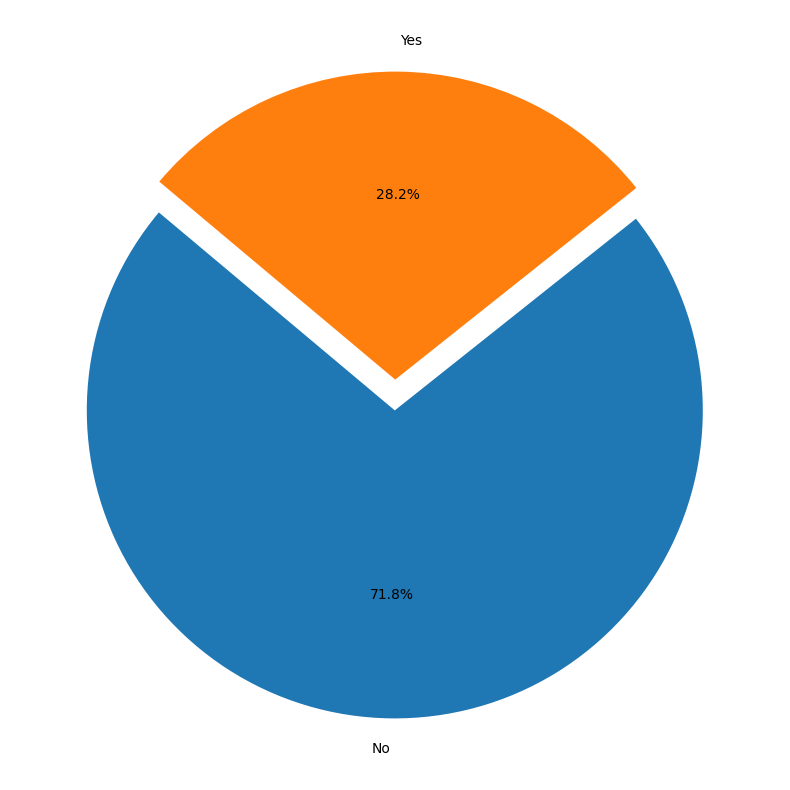

In [214]:
target_count = dataset['Recurred'].value_counts()
explode = [0.05] * len(target_count)

plt.figure(figsize=(10,10))
plt.pie(
    target_count,
    labels=target_count.index,
    explode=explode,
    startangle=140,
    autopct="%1.1f%%"
)

#### *b. Inspeksi Distribusi Value Unik Fitur Kategorik*

In [215]:
def check_value(dataset, col):

    for cols in col:
        print("=" * 40)
        print(f"Kolom: {cols}")
        print("=" * 40)
        print(dataset[cols].value_counts(dropna=False))
        print(f"\n")

check_value(dataset, fitur_ordinal)

Kolom: Focality
Focality
Uni-Focal      247
Multi-Focal    136
Name: count, dtype: int64


Kolom: Risk
Risk
Low             249
Intermediate    102
High             32
Name: count, dtype: int64


Kolom: T
T
T2     151
T3a     96
T1a     49
T1b     43
T4a     20
T3b     16
T4b      8
Name: count, dtype: int64


Kolom: N
N
N0     268
N1b     93
N1a     22
Name: count, dtype: int64


Kolom: M
M
M0    365
M1     18
Name: count, dtype: int64


Kolom: Stage
Stage
I      333
II      32
IVB     11
III      4
IVA      3
Name: count, dtype: int64


Kolom: Response
Response
Excellent                 208
Structural Incomplete      91
Indeterminate              61
Biochemical Incomplete     23
Name: count, dtype: int64


Kolom: Recurred
Recurred
No     275
Yes    108
Name: count, dtype: int64




### 7. Bivariate Analysis

#### *a, Inspeksi Distribusi Fitur Berdasarkan Target*

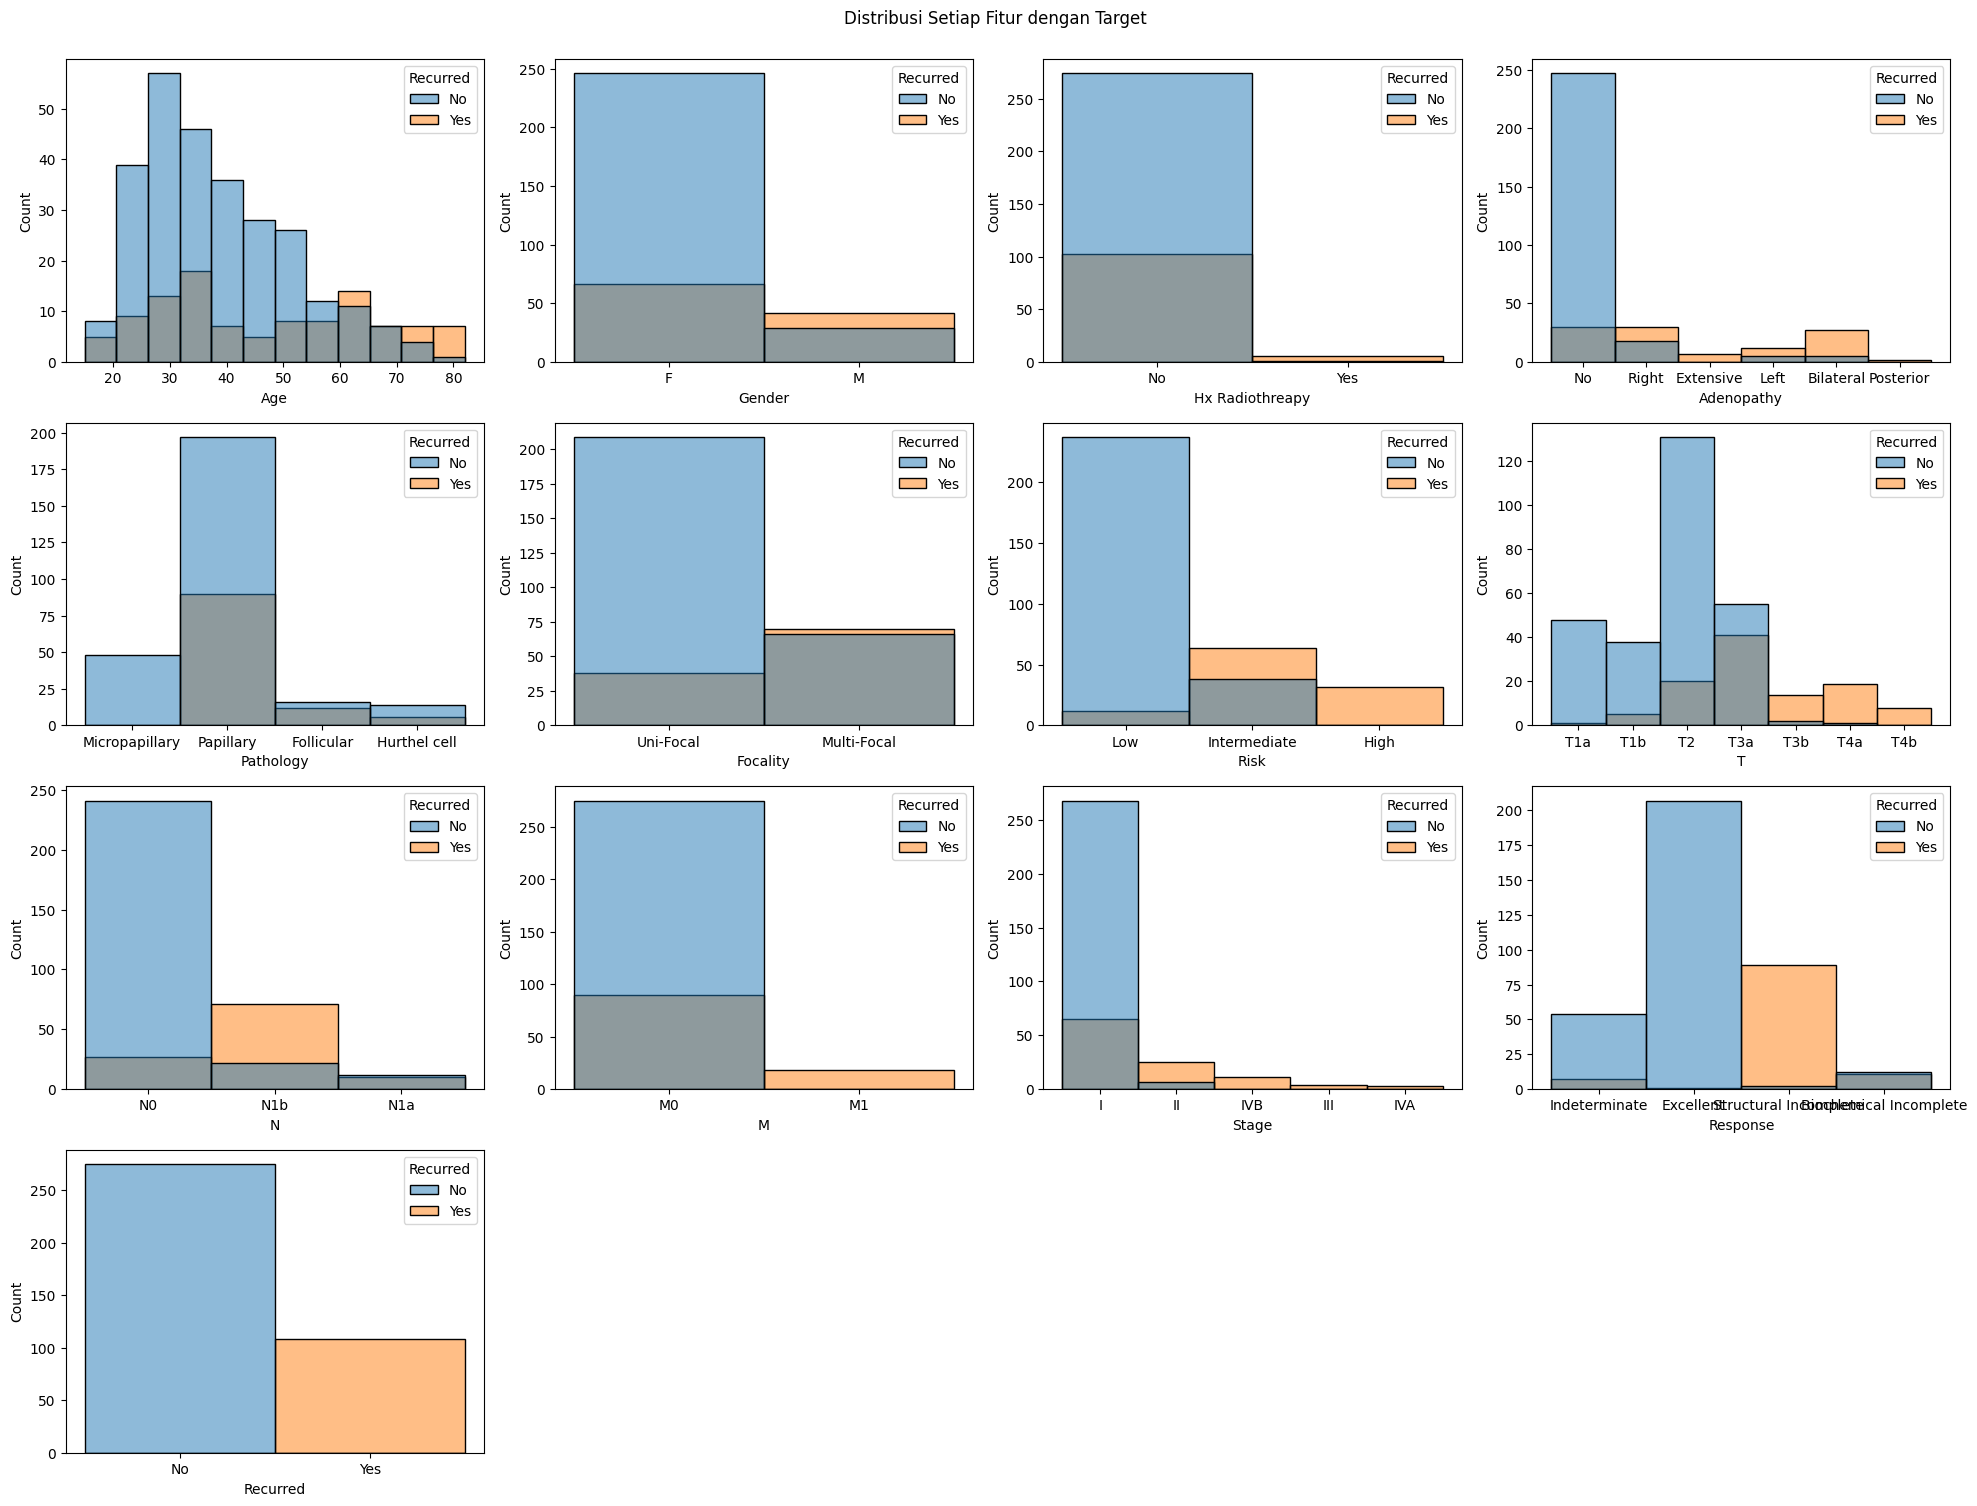

In [216]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(dataset):
    plt.subplot(4, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Recurred"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

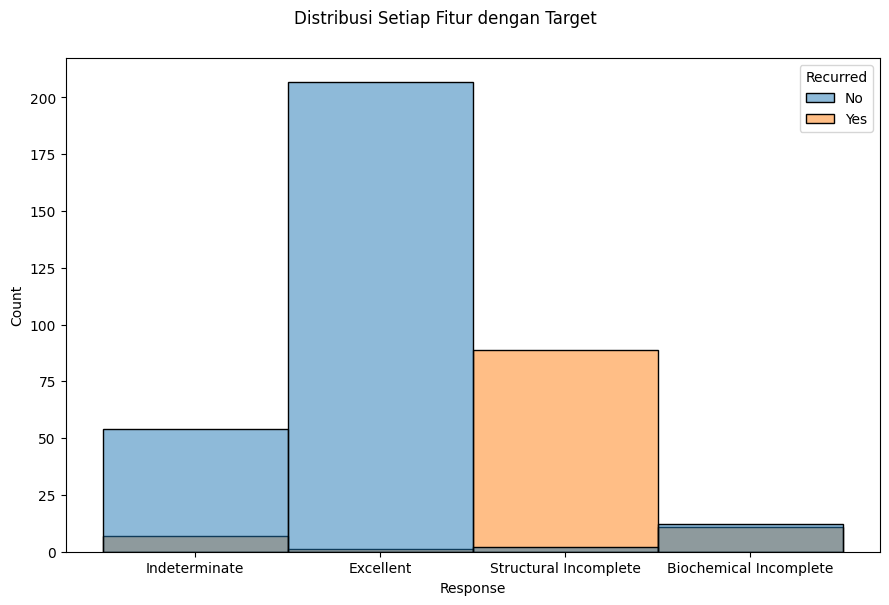

In [217]:
plt.figure(figsize=(9, 6))
sns.histplot(x=dataset["Response"], hue=dataset["Recurred"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

### 9. Dataset Sementara

#### *a. Copy Dataset Master*

In [218]:
dataset_copy = dataset.copy()

#### *b. Data Preprocessing*

encode fitur nominal

In [219]:
def label_encode(dataset, col):
    for cols in col:
        dataset[cols] = pd.factorize(dataset[cols])[0]
    return dataset

dataset_copy = label_encode(dataset_copy, fitur_nominal)

Map Focality

In [220]:
map_focality = {'Uni-Focal' : 1, 'Multi-Focal' : 2}
dataset_copy['Focality'] = dataset_copy['Focality'].map(map_focality)

In [221]:
dataset_copy['Focality'].value_counts()

Focality
1    247
2    136
Name: count, dtype: int64

Map Risk

In [222]:
map_risk = {'Low' : 1, 'Intermediate' : 2, 'High': 3}
dataset_copy['Risk'] = dataset_copy['Risk'].map(map_risk)

In [223]:
dataset_copy['Risk'].value_counts()

Risk
1    249
2    102
3     32
Name: count, dtype: int64

Map T

In [224]:
map_t = {'T1a': 1, 'T1b' : 2, 'T2' : 3, 'T3a' : 4, 'T3b' : 5, 'T4a' : 5, 'T4b' : 6}
dataset_copy['T'] = dataset_copy["T"].map(map_t)

In [225]:
dataset_copy['T'].value_counts()

T
3    151
4     96
1     49
2     43
5     36
6      8
Name: count, dtype: int64

Map N

In [226]:
map_n = {'N0' : 1, "N1a":2, "N1b" : 3}
dataset_copy['N'] = dataset_copy['N'].map(map_n)

In [227]:
dataset_copy['N'].value_counts()

N
1    268
3     93
2     22
Name: count, dtype: int64

Map M

In [228]:
map_m = {'M0' : 1, 'M1' : 2}
dataset_copy['M'] = dataset_copy['M'].map(map_m)

In [229]:
dataset_copy['M'].value_counts()

M
1    365
2     18
Name: count, dtype: int64

Map Stage

In [230]:
map_stage = {'I' : 1, 'II' : 2, 'III' : 3, 'IVA' : 4, 'IVB' : 5}
dataset_copy['Stage'] = dataset_copy['Stage'].map(map_stage)

In [231]:
dataset_copy['Stage'].value_counts()

Stage
1    333
2     32
5     11
3      4
4      3
Name: count, dtype: int64

Map Response

In [232]:
map_response = {'Excellent' : 1, 'Structural Incomplete' : 4, 'Indeterminate' : 2, 'Biochemical Incomplete' : 3}
dataset_copy['Response'] = dataset_copy['Response'].map(map_response)

In [233]:
dataset_copy['Response'].value_counts()

Response
1    208
4     91
2     61
3     23
Name: count, dtype: int64

Map Target

In [234]:
dataset_copy['Recurred'] = dataset_copy['Recurred'].astype(object)
dataset_copy['Recurred'] = dataset_copy['Recurred'].astype(int)
# map_recurred = {'No' : 0, 'Yes' : 1}
# dataset_copy['Recurred'] = dataset_copy['Recurred'].map(map_recurred)

In [235]:
dataset_copy['Recurred'].value_counts()

Recurred
0    275
1    108
Name: count, dtype: int64

Feature Engineering

In [236]:
dataset_copy["Spread Level"] = dataset_copy["T"] + dataset_copy["N"] + dataset_copy["M"]

#### *c. Inspeksi Ulang Dataset Sementara*

In [237]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              383 non-null    int64
 1   Gender           383 non-null    int64
 2   Hx Radiothreapy  383 non-null    int64
 3   Adenopathy       383 non-null    int64
 4   Pathology        383 non-null    int64
 5   Focality         383 non-null    int64
 6   Risk             383 non-null    int64
 7   T                383 non-null    int64
 8   N                383 non-null    int64
 9   M                383 non-null    int64
 10  Stage            383 non-null    int64
 11  Response         383 non-null    int64
 12  Recurred         383 non-null    int64
 13  Spread Level     383 non-null    int64
dtypes: int64(14)
memory usage: 42.0 KB


In [238]:
dataset_copy.isna().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
Spread Level       0
dtype: int64

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [239]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

In [240]:
real_fitur = ['Age', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Gender', "Hx Radiothreapy", 'Adenopathy', 'Pathology']
fitur = dataset_copy[real_fitur]
target = dataset_copy["Recurred"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
0,Age,2.250758
10,Adenopathy,1.009734
8,Gender,0.765470
11,Pathology,0.714053
3,T,0.712992
7,Response,0.629668
2,Risk,0.446936
4,N,0.400251
9,Hx Radiothreapy,0.379626
1,Focality,0.309133


C:\Users\nizam\AppData\Local\Temp\ipykernel_14184\2098602569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")


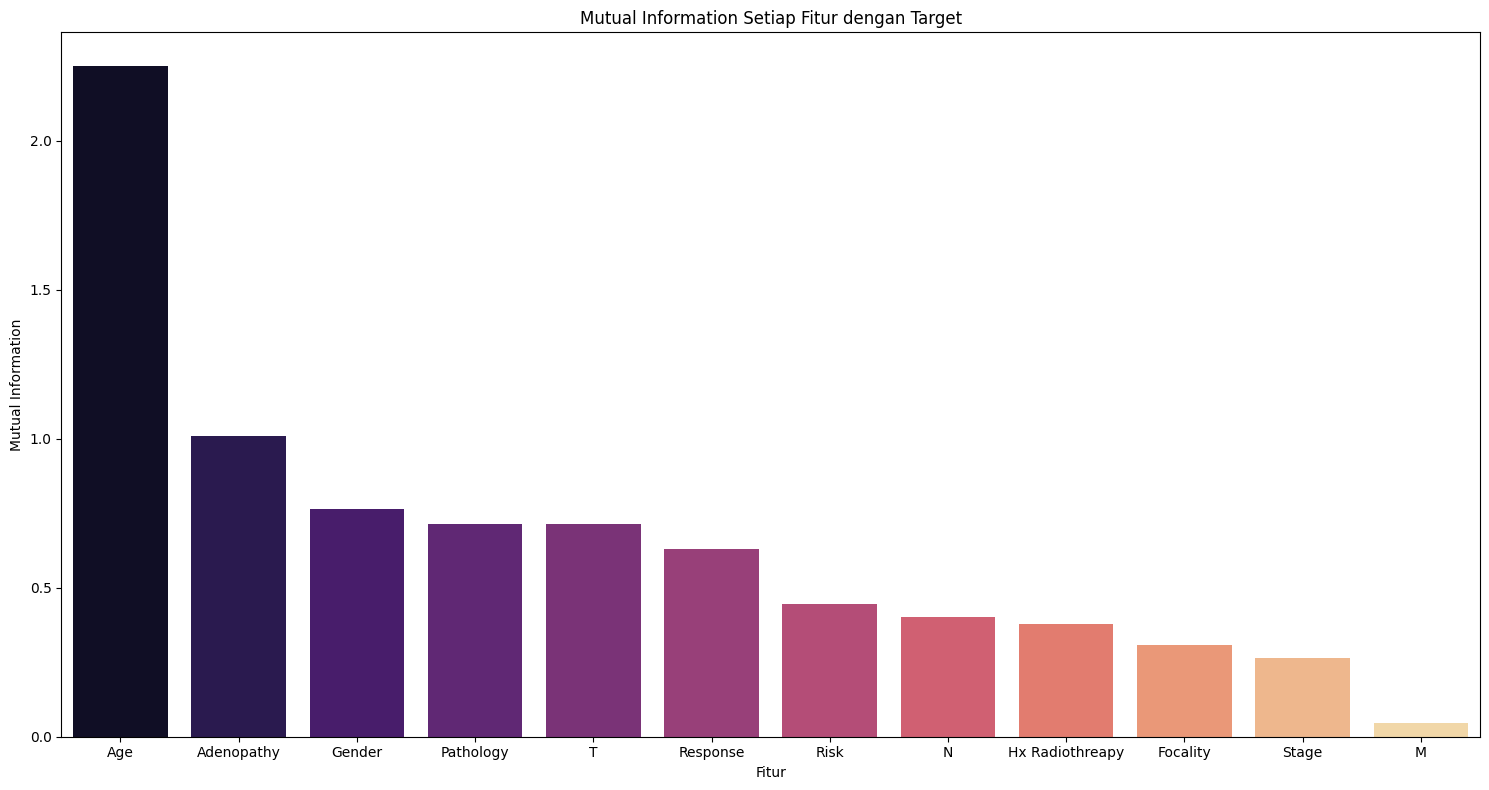

In [241]:
plt.figure(figsize=(15, 8))
sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")

plt.title("Mutual Information Setiap Fitur dengan Target")
plt.xlabel("Fitur")
plt.ylabel("Mutual Information")
plt.tight_layout()
plt.show()

#### *b. Method Kendall*

In [242]:
def kendall_tau(x, y):
    n = len(x)
    concordant = 0
    disconcordant = 0

    for i in range(n - 1):
        for j in range(i + 1, n):

            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            
            elif x_diff * y_diff < 0:
                disconcordant += 1

    if (concordant - disconcordant) == 0:
        return 0
    
    return (concordant - disconcordant) / (concordant + disconcordant)

Fitur Diskrit

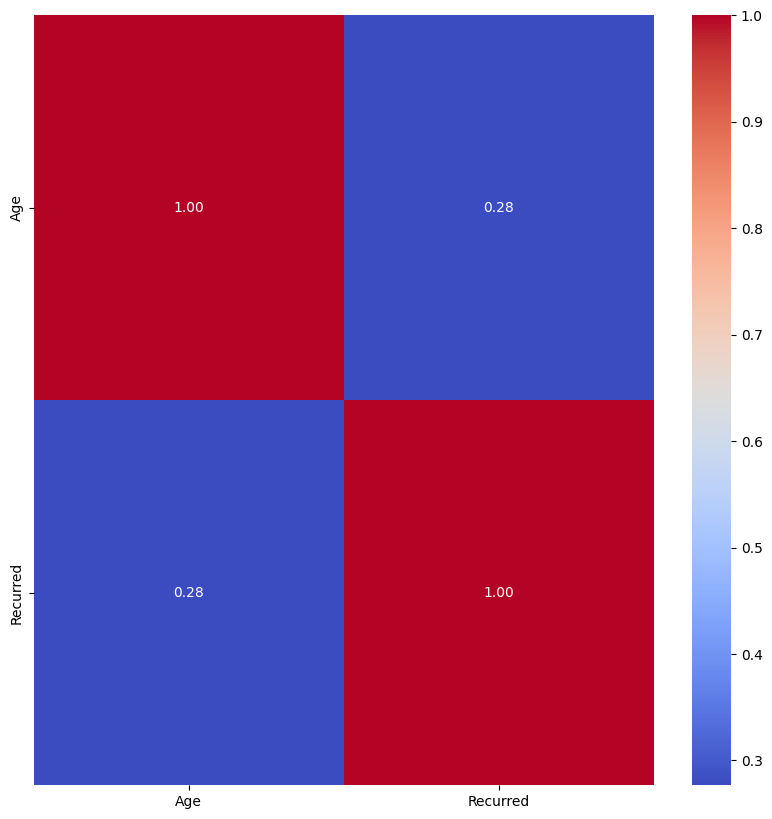

In [243]:
kendall_diskrit = pd.DataFrame(index=fitur_diskrit, columns=fitur_diskrit)

for col1 in fitur_diskrit:
    for col2 in fitur_diskrit:
        kendall_diskrit.loc[col1, col2] = kendall_tau(dataset_copy[col1].values, dataset_copy[col2].values)

kendall_diskrit = kendall_diskrit.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(kendall_diskrit, cmap='coolwarm', fmt='.2f', annot=True)
plt.show()

Fitur Ordinal

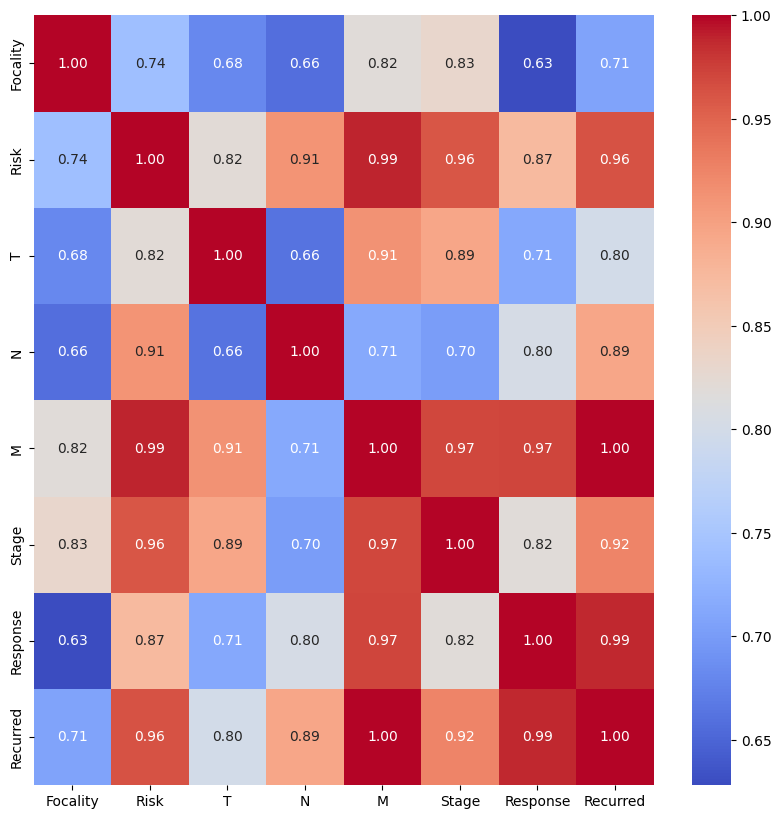

In [244]:
kendall_ordinal = pd.DataFrame(index=fitur_ordinal, columns=fitur_ordinal)

for col1 in fitur_ordinal:
    for col2 in fitur_ordinal:
        kendall_ordinal.loc[col1, col2] = kendall_tau(dataset_copy[col1].values, dataset_copy[col2].values)

kendall_ordinal = kendall_ordinal.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(kendall_ordinal, cmap='coolwarm', fmt='.2f', annot=True)
plt.show()

#### *c. Method Chi Square*

In [245]:
def chi_square_test(data, col1, col2):

    observed = pd.crosstab(data[col1], data[col2])
    totals = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / totals
    chi_square = ((observed.values - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    return chi_square, dof

In [246]:
chi_scores = []

for col in dataset_copy[fitur_nominal]:
    chi, dof = chi_square_test(dataset_copy, col, "Recurred")
    print(f"{col} | Degree of Freedom: {dof} : Chi Squares: {chi}")
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=["Feature", "Chi Scores"])
chi_df = chi_df.sort_values(by="Chi Scores", ascending=False)

Gender | Degree of Freedom: 1 : Chi Squares: 41.25221045777384
Hx Radiothreapy | Degree of Freedom: 1 : Chi Squares: 11.649980197107858
Adenopathy | Degree of Freedom: 5 : Chi Squares: 157.04429320211565
Pathology | Degree of Freedom: 3 : Chi Squares: 23.27043458980044
Recurred | Degree of Freedom: 1 : Chi Squares: 383.0


C:\Users\nizam\AppData\Local\Temp\ipykernel_14184\542725323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette="magma")


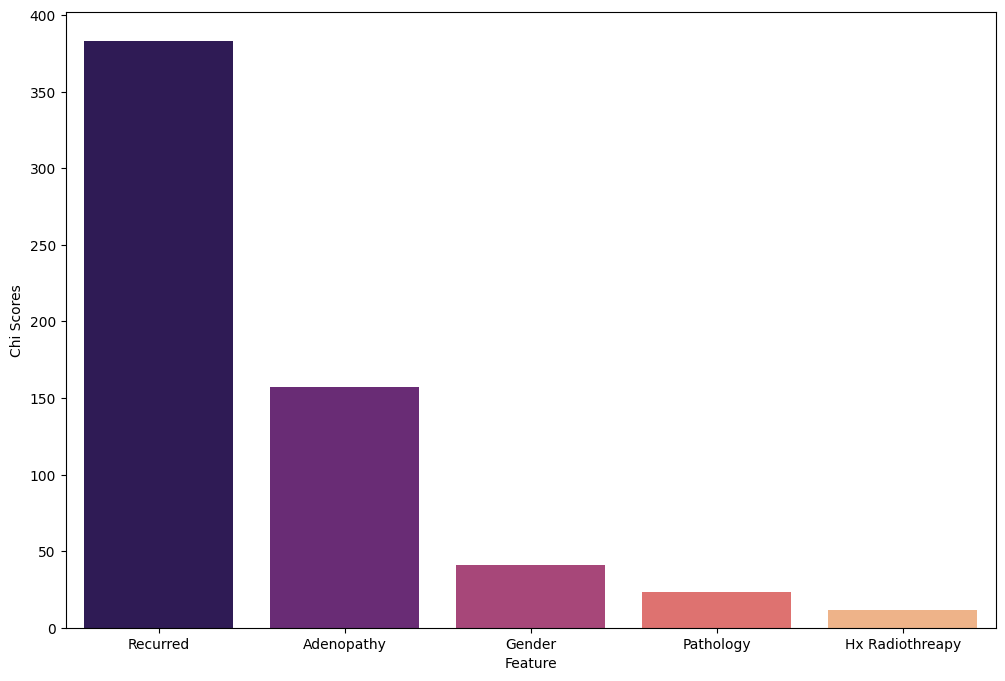

In [247]:
plt.figure(figsize=(12, 8))
sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette="magma")
plt.show()

### 11. Inspeksi Outlier

#### a. Cek Rentang Data

In [248]:
def check_range(dataset, cols):
    for col in cols:
        data = dataset[col].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_iqr = ((data < lower_bound) | (data > upper_bound)).sum()
        
        mean = data.mean()
        std = data.std()
        z_scores = (data - mean) / std
        outlier_z = (abs(z_scores) > 3).sum()

        print(f"Kolom: {col}")
        print("-" * 50)
        print(f"IQR Method:")
        print(f" - Q1: {Q1}")
        print(f" - Q3: {Q3}")
        print(f" - IQR: {IQR}")
        print(f" - Batas Bawah: {lower_bound}")
        print(f" - Batas Atas: {upper_bound}")
        print(f" - Jumlah outlier (IQR): {outlier_iqr}")
        print()
        
        print(f"Z-Score Method:")
        print(f" - Mean: {mean}")
        print(f" - Std Dev: {std}")
        print(f" - Jumlah outlier (Z-Score > 3): {outlier_z}")

check_range(dataset_copy, fitur_diskrit)

Kolom: Age
--------------------------------------------------
IQR Method:
 - Q1: 29.0
 - Q3: 51.0
 - IQR: 22.0
 - Batas Bawah: -4.0
 - Batas Atas: 84.0
 - Jumlah outlier (IQR): 0

Z-Score Method:
 - Mean: 40.866840731070496
 - Std Dev: 15.134493807858814
 - Jumlah outlier (Z-Score > 3): 0
Kolom: Recurred
--------------------------------------------------
IQR Method:
 - Q1: 0.0
 - Q3: 1.0
 - IQR: 1.0
 - Batas Bawah: -1.5
 - Batas Atas: 2.5
 - Jumlah outlier (IQR): 0

Z-Score Method:
 - Mean: 0.2819843342036554
 - Std Dev: 0.450554318003077
 - Jumlah outlier (Z-Score > 3): 0


#### b. Cek Outlier

## ***B. Feature Selection***

In [249]:
feature_cols = ['Age', "Focality", "T", "N", "M", "Stage", "Response"]

## ***C. Data Preprocessing***

### 2. Encode Fitur

Response

In [250]:
map_response = {'Excellent' : 1, 'Structural Incomplete' : 4, 'Indeterminate' : 2, 'Biochemical Incomplete' : 3}
dataset['Response'] = dataset['Response'].map(map_response)

Focality

In [251]:
map_focality = {'Uni-Focal' : 1, 'Multi-Focal' : 2}
dataset['Focality'] = dataset['Focality'].map(map_focality)

Risk

In [252]:
map_risk = {'Low' : 1, 'Intermediate' : 2, 'High': 3}
dataset['Risk'] = dataset['Risk'].map(map_risk)

T

In [253]:
map_t = {'T1a': 1, 'T1b' : 2, 'T2' : 3, 'T3a' : 4, 'T3b' : 5, 'T4a' : 5, 'T4b' : 6}
dataset['T'] = dataset["T"].map(map_t)

N

In [254]:
map_n = {'N0' : 1, "N1a":2, "N1b" : 3}
dataset['N'] = dataset['N'].map(map_n)

M

In [255]:
map_m = {'M0' : 1, 'M1' : 2}
dataset['M'] = dataset['M'].map(map_m)

Stage

In [256]:
map_stage = {'I' : 1, 'II' : 2, 'III' : 3, 'IVA' : 4, 'IVB' : 5}
dataset['Stage'] = dataset['Stage'].map(map_stage)

Recurred


In [257]:
map_recurred = {"Yes" : 1, "No" : 0}
dataset['Recurred'] = dataset['Recurred'].map(map_recurred)

## ***D. Splitting Dataset***

In [258]:
def stratified_split(dataset, target_column, train_size = 0.8, frac = 1, random_state = 42):
    
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_label in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_label]
        class_data = class_data.sample(random_state = random_state, frac = frac)

        split_idx = int(len(class_data) * train_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, 'Recurred')

In [259]:
dataset_training

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,37,F,No,No,Micropapillary,1,1,1,1,1,1,1,0
1,29,F,No,No,Papillary,1,1,3,1,1,1,1,0
2,25,F,No,Right,Papillary,2,1,3,3,1,1,1,0
3,32,F,No,No,Papillary,1,1,3,1,1,1,1,0
4,20,F,No,No,Papillary,1,2,3,2,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,56,F,No,No,Follicular,2,1,4,1,1,1,4,1
302,68,M,No,Bilateral,Papillary,2,2,5,3,1,3,4,1
303,26,F,No,Left,Papillary,1,2,4,3,2,1,4,1
304,40,M,No,Bilateral,Papillary,2,3,6,3,1,1,4,1


## ***E. Data Oversampling***

In [260]:
def random_oversample(dataset, target_column, additional_size = None):

    classes = dataset[target_column].value_counts()
    resampled_data = [dataset]

    for label, size in classes.items():
        additional_data = dataset[dataset[target_column] == label]
        minority_class_data = additional_data.sample(n=additional_size[label], random_state = 42)
        resampled_data.append(minority_class_data)
    
    final_dataset = pd.concat(resampled_data).sample(frac = 1, random_state=42).reset_index(drop=True)
    return final_dataset

## ***F. Feature Target Declaration***

In [261]:
X_train = dataset_training[feature_cols]
X_test = dataset_testing[feature_cols]
# X_train = dataset_training[all_feature_cols]
# X_test = dataset_testing[all_feature_cols]

y_train = dataset_training["Recurred"]
y_test = dataset_testing["Recurred"]

## ***G. Dimension Reduction***

So that the code knows which is categorical which is not

In [262]:
X_train['Age'] = X_train['Age'].astype(float)
X_test['Age'] = X_test['Age'].astype(float)

C:\Users\nizam\AppData\Local\Temp\ipykernel_14184\461709556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Age'] = X_train['Age'].astype(float)
C:\Users\nizam\AppData\Local\Temp\ipykernel_14184\461709556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Age'] = X_test['Age'].astype(float)


In [263]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       306 non-null    float64
 1   Focality  306 non-null    int64  
 2   T         306 non-null    int64  
 3   N         306 non-null    int64  
 4   M         306 non-null    int64  
 5   Stage     306 non-null    int64  
 6   Response  306 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 16.9 KB


### 1. Principal Component Analysis

In [264]:
def pca_fit(X, n_components):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_std[X_std == 0] = 1 
    
    X_scaled = (X - X_mean) / X_std

    cov = np.cov(X_scaled, rowvar=False)

    if np.ndim(cov) == 0:
        cov = np.array([[cov]])

    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]
    X_pca = np.dot(X_scaled, components)
    explained_variance = eigenvalues[:n_components]

    return X_pca, components, X_mean, X_std, explained_variance


### 2. Multiple Correspondence Analysis

In [265]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()
    
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)
    
    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)
    
    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data

In [ ]:
def famd_fit(df, n_components):

    float_cols = df.select_dtypes(include = ['float']).columns
    int_cols = df.select_dtypes(include = ['int']).columns

    X_num =df[float_cols].to_numpy()
    X_pca, pca_components, pca_mean, pca_std, _ = pca_fit(X_num, X_num.shape[1])

    X_cat = df[int_cols]
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, min(n_components, 50))

    X_combined = np.hstack([X_pca, X_mca])
    X_famd, famd_components, _, _, _ = pca_fit(X_combined, n_components)

    return {
        'float_cols' : float_cols,
        'int_cols' : int_cols,
        'X_pca' : X_pca,
        'pca_components' : pca_components,
        'pca_mean' : pca_mean,
        'pca_std' : pca_std,
        'X_mca' : X_mca,
        'mca_components' : mca_components,
        'dummy_columns' : dummy_columns,
        'X_famd' : X_famd,
        'famd_components' : famd_components
    }

def famd_transform(df, model):
    X_num = df[model['float_cols']].to_numpy()
    safe_std = np.where(model['pca_std'] == 0, 1, model['pca_std'])
    
    X_scaled = (X_num - model['pca_mean']) / safe_std
    X_pca = np.dot(X_scaled, model['pca_components'])

    X_cat = df[model['int_cols']]
    X_mca = mca_transform(X_cat, model['mca_components'], model['dummy_columns'])

    X_combined = np.hstack([X_pca, X_mca])
    X_famd = np.dot((X_combined - np.mean(X_combined, axis=0)) / np.std(X_combined, axis = 0), model['famd_components'])
    return X_famd

In [267]:
famd_model = famd_fit(X_train, n_components=2)
X_train_famd = famd_model['X_famd']
X_test = famd_transform(X_test, famd_model)

famd_df = pd.DataFrame(X_train_famd, columns=['Dimensi 1', 'Dimensi 2'])
famd_df['target'] = y_train.values

### 4. Visualisasi Data Training Setelah FAMD

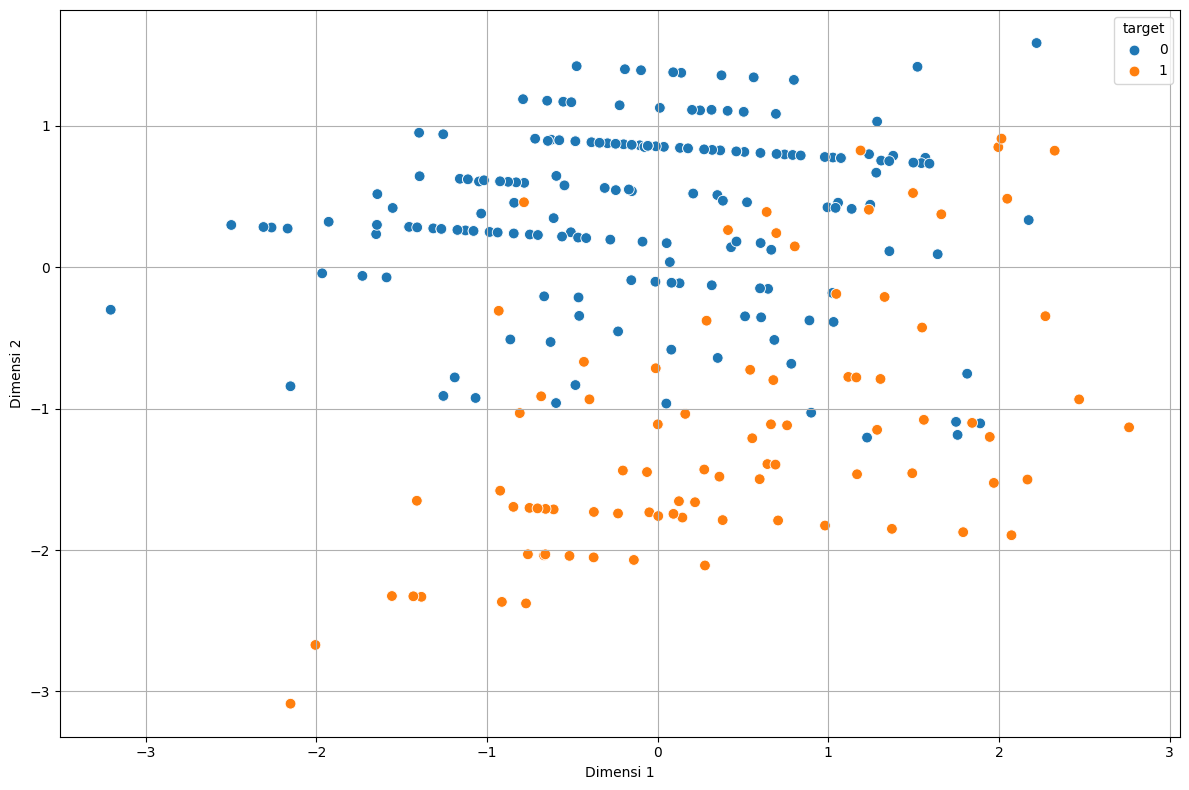

In [270]:
plt.figure(figsize=(12, 8))
sns.scatterplot(famd_df, x="Dimensi 1", y = "Dimensi 2", hue='target', palette='tab10', s=60)
plt.grid(True)
plt.tight_layout()
plt.show()

# **III. Modeling**

## ***A. Modelling***

## ***B. Hasil Prediksi***

### 1. Training Model

### 2. Testing Model

## ***C. Visualisasi Model***

### 1. Uji Coba Data Baru

### 2. Reverse Encoding untuk Visualisasi

### 3. Distribusi Hasil Prediksi

### 4. Confusion Matrix

### 5. Analisis Korelasi Fitur dengan Fitur

#### *a. Fitur Numerik*

#### *b. Fitur Kategorikal*

## ***D. Evaluasi Model***

### 1. Confusion Matrix

#### *a. Fungsi Confusion Matrix*

#### *b. Evaluasi Training Model*

#### *c. Evaluasi Testing Model*

### 2. Bias dan Variance Model

### 3. K-Fold Cross Validation

#### *a. Fungsi K-Fold*

#### *b. Model K-Fold*

# **IV. Final Evaluation**
---

Copyright @ 2025. SMK Negeri 8 Malang. All rights reserved.